In [1]:
# Install required packages
%pip install diffusers transformers accelerate torch torchvision torchaudio


In [ ]:
import torch
from diffusers import StableDiffusionXLPipeline
import gc

# Clear any cached memory from previous runs
torch.cuda.empty_cache()
gc.collect()

# Load the stable diffusion XL base 1.0 model
# pipe = StableDiffusionXLPipeline.from_pretrained(
#     "stabilityai/stable-diffusion-xl-base-1.0", 
#     torch_dtype=torch.float16, 
#     variant="fp16", 
#     use_safetensors=True
# )

pipe = StableDiffusionXLPipeline.from_single_file(
    "https://huggingface.co/wangkanai/sdxl-fp8/blob/main/checkpoints/sdxl/sdxl-base.safetensors",
    torch_dtype=torch.float8, # Keep pipeline execution in fp16
)
pipe.to("cuda")

# Enable memory optimizations instead of loading everything onto GPU VRAM at once
pipe.enable_model_cpu_offload() # Dynamically offloads model layers to CPU to free VRAM
pipe.enable_vae_slicing()       # Decodes images in slices to save VRAM

print("Model loaded with memory optimizations (CPU offload & VAE slicing)")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Model loaded with memory optimizations (CPU offload & VAE slicing)


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


Token indices sequence length is longer than the specified maximum sequence length for this model (164 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['0." the screen flashes red with an " error " message. she looks around the room as the smoke gets thicker and darker, looking trapped and scared. [ part 3 ] sudden transition to a bright, safe, clear living room. the girl is now calm and wearing a heroic cape. she looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. high - quality lighting, expressive character animation, 4 k.']


Generating image with prompt: 'Animated 3D cinematic style. [PART 1] A young Asian girl in a living room filled with hazy smoke. She picks up a glowing smartphone with trembling hands. Close-up on the keypad; her finger hovers over the screen with a confused, anxious expression. [PART 2] She taps a wrong sequence like "999" or "000." The screen flashes red with an "Error" message. She looks around the room as the smoke gets thicker and darker, looking trapped and scared. [PART 3] Sudden transition to a bright, safe, clear living room. The girl is now calm and wearing a heroic cape. She looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. High-quality lighting, expressive character animation, 4k.'


Token indices sequence length is longer than the specified maximum sequence length for this model (164 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['0." the screen flashes red with an " error " message. she looks around the room as the smoke gets thicker and darker, looking trapped and scared. [ part 3 ] sudden transition to a bright, safe, clear living room. the girl is now calm and wearing a heroic cape. she looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. high - quality lighting, expressive character animation, 4 k.']


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


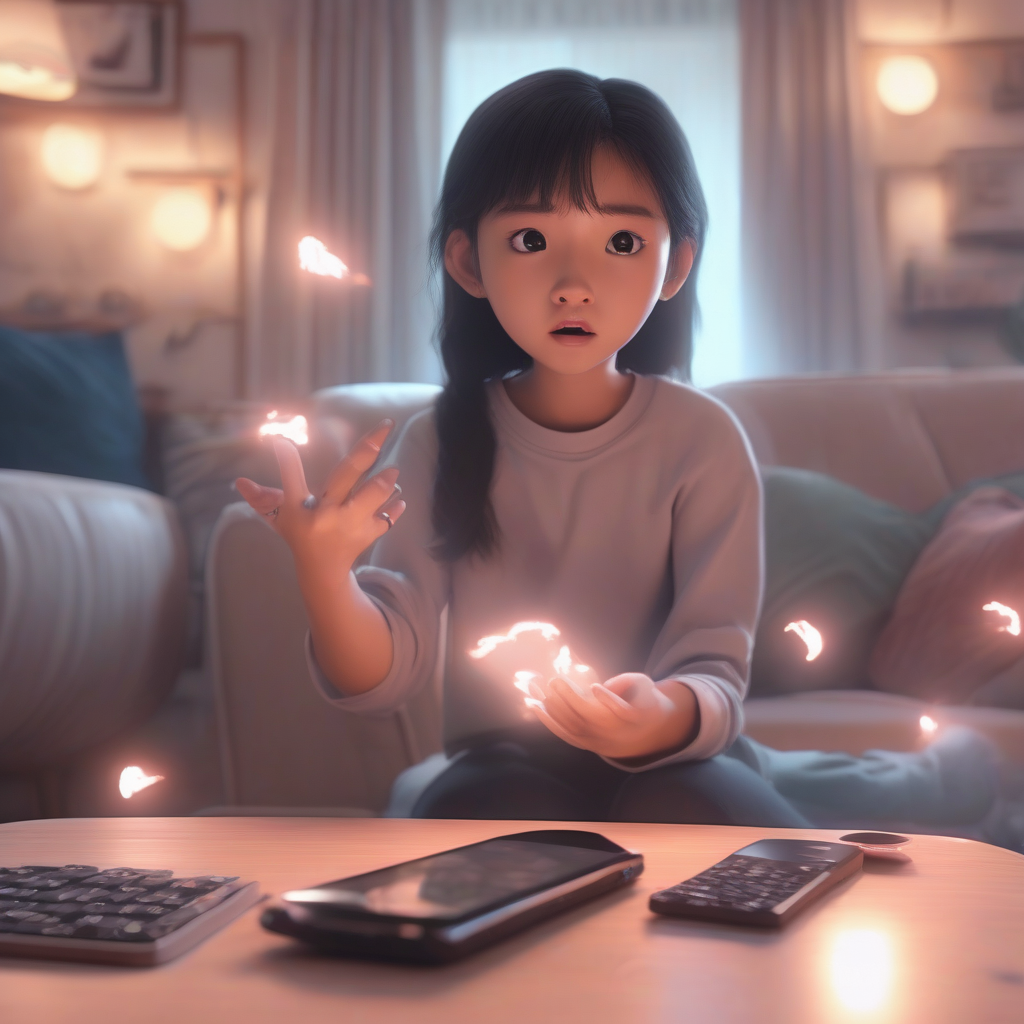

In [2]:
# Generate an image programmatically
from copy import Error

prompt = 'Animated 3D cinematic style. [PART 1] A young Asian girl in a living room filled with hazy smoke. She picks up a glowing smartphone with trembling hands. Close-up on the keypad; her finger hovers over the screen with a confused, anxious expression. [PART 2] She taps a wrong sequence like "999" or "000." The screen flashes red with an "Error" message. She looks around the room as the smoke gets thicker and darker, looking trapped and scared. [PART 3] Sudden transition to a bright, safe, clear living room. The girl is now calm and wearing a heroic cape. She looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. High-quality lighting, expressive character animation, 4k.'
negative_prompt = ""    

print(f"Generating image with prompt: '{prompt}'")
image = pipe(prompt=prompt, negative_prompt=negative_prompt, num_inference_steps=25).images[0]

# Display the image
image

In [ ]:
# !pip install optimum-quanto

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 22.3 MB/s eta 0:00:00


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['0." the screen flashes red with an " error " message. she looks around the room as the smoke gets thicker and darker, looking trapped and scared. [ part 3 ] sudden transition to a bright, safe, clear living room. the girl is now calm and wearing a heroic cape. she looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. high - quality lighting, expressive character animation, 4 k.']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['0." the screen flashes red with an " error " message. she looks around the room as the smoke gets thicker and darker, looking trapped and scared. [ part 3 ] sudden transition to a bright, safe, clear living room. the girl is now calm and wearing a heroic cape. she looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. high - quality l

Generating image with prompt: 'Animated 3D cinematic style. [PART 1] A young Asian girl in a living room filled with hazy smoke. She picks up a glowing smartphone with trembling hands. Close-up on the keypad; her finger hovers over the screen with a confused, anxious expression. [PART 2] She taps a wrong sequence like "999" or "000." The screen flashes red with an "Error" message. She looks around the room as the smoke gets thicker and darker, looking trapped and scared. [PART 3] Sudden transition to a bright, safe, clear living room. The girl is now calm and wearing a heroic cape. She looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. High-quality lighting, expressive character animation, 4k.'


  0%|          | 0/20 [00:00<?, ?it/s]

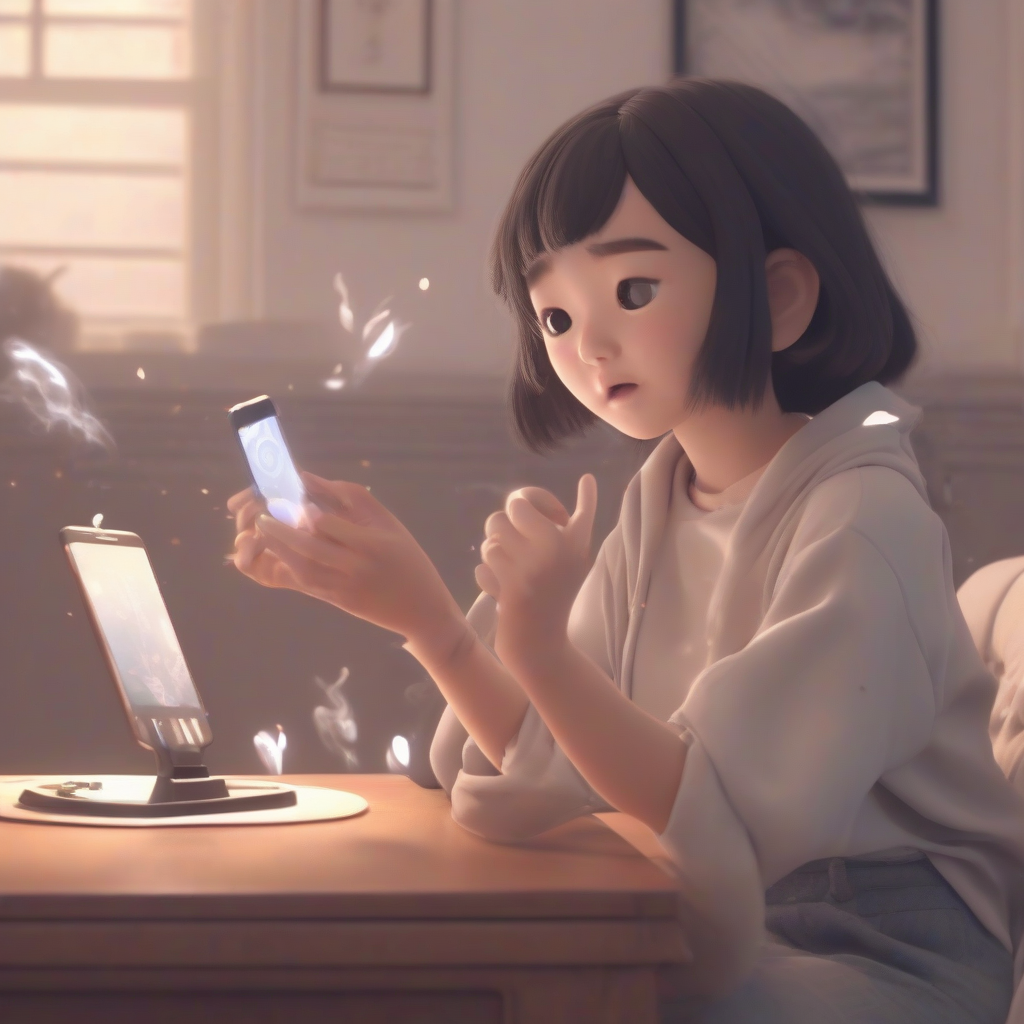

In [5]:
# Generate an image programmatically
from copy import Error
import torch
import gc

# Free up reserved unused memory right before generating
gc.collect()
torch.cuda.empty_cache()

prompt = 'Animated 3D cinematic style. [PART 1] A young Asian girl in a living room filled with hazy smoke. She picks up a glowing smartphone with trembling hands. Close-up on the keypad; her finger hovers over the screen with a confused, anxious expression. [PART 2] She taps a wrong sequence like "999" or "000." The screen flashes red with an "Error" message. She looks around the room as the smoke gets thicker and darker, looking trapped and scared. [PART 3] Sudden transition to a bright, safe, clear living room. The girl is now calm and wearing a heroic cape. She looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. High-quality lighting, expressive character animation, 4k.'
negative_prompt = ""    

print(f"Generating image with prompt: '{prompt}'")
image = pipe(prompt=prompt, negative_prompt=negative_prompt, num_inference_steps=20).images[0]

# Display the image
image

In [6]:
!pip -q install pyngrok

In [7]:
from pyngrok import ngrok

ngrok.set_auth_token("2jgskLRiOe7GhBcW8GY1KA7rck6_2paMPJxXTQDagpfnfjdDd")

In [ ]:
def generate_image(prompt):
    """
    This function takes the text prompt from the Gradio UI,
    passes it to the GPU, and returns the generated image.
    """
    gc.collect()
    torch.cuda.empty_cache()

    # The pipeline returns a list of images; we take the first one [0]
    image = pipe(prompt=prompt, negative_prompt="", num_inference_steps=25).images[0]
    return image

In [5]:
!pip install diffusers transformers accelerate torch gradio pyngrok

In [18]:
import gradio as gr

In [19]:
demo = gr.Interface(
    fn=generate_image,
    inputs=gr.Textbox(label="Enter your prompt here", placeholder="A futuristic city at sunset, cyberpunk style..."),
    outputs=gr.Image(label="Generated Image"),
    title="My Colab Image Generator",
    description="Running on a Colab GPU, tunneled through ngrok."
)

In [20]:
ngrok.kill() 

# Expose port 7860 (Gradio's default port)
public_url = ngrok.connect(7860)
print(f"✅ Your image generator is live at: {public_url}")

# ---------------------------------------------------------
# 5. Launch the App
# ---------------------------------------------------------
# We run the app locally, and ngrok handles the forwarding.
demo.launch(server_name="127.0.0.1", server_port=7860)

✅ Your image generator is live at: NgrokTunnel: "https://34dd-35-240-185-68.ngrok-free.app" -> "http://localhost:7860"
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e3c5fc018cae41695a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


In [6]:
!pip install gradio_client

In [22]:
from gradio_client import Client

client = Client("https://34dd-35-240-185-68.ngrok-free.app/")
result = client.predict(
	prompt="Hello!!",
	api_name="/predict"
)
print(result)

Loaded as API: https://34dd-35-240-185-68.ngrok-free.app/ ✔


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


/tmp/gradio/b9a09f1a117014eeee9023489b579a92fa63ceb3f778fbf2210ab0e49b88bfcf/image.webp


In [8]:
# Cell 1: install deps
!pip -q install fastapi uvicorn pyngrok diffusers transformers accelerate torch pillow

In [9]:
# Cell 3: FastAPI app with GET image endpoint
from fastapi import FastAPI, Query
from fastapi.responses import StreamingResponse, JSONResponse
from io import BytesIO

app = FastAPI(title="Colab Image API")

@app.get("/")
def health():
    return {"status": "ok", "message": "API is running"}

@app.get("/generate-image")
def generate_image(prompt: str = Query(..., min_length=3), steps: int = 20):
    try:
        # optional cleanup before generation
        gc.collect()
        torch.cuda.empty_cache()

        image = pipe(
            prompt=prompt,
            negative_prompt="",
            num_inference_steps=steps
        ).images[0]

        buf = BytesIO()
        image.save(buf, format="PNG")
        buf.seek(0)
        return StreamingResponse(buf, media_type="image/png")
    except Exception as e:
        return JSONResponse(status_code=500, content={"error": str(e)})

In [ ]:
# Cell 4: expose API publicly from Colab
from pyngrok import ngrok
import threading
import uvicorn

# add your ngrok token once
# ngrok.set_auth_token("YOUR_NGROK_TOKEN")

def run_api():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_api, daemon=True)
thread.start()

public_url = ngrok.connect(8000)
print("Public API URL:", public_url)
print("Try:", f"{public_url}/generate-image?prompt=a%20cute%20robot%20in%20a%20forest")

INFO:     Started server process [8102]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


Public API URL: NgrokTunnel: "https://aa20-34-124-212-81.ngrok-free.app" -> "http://localhost:8000"
Try: NgrokTunnel: "https://aa20-34-124-212-81.ngrok-free.app" -> "http://localhost:8000"/generate-image?prompt=a%20cute%20robot%20in%20a%20forest


  0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


: 